Using file: oct_10_0019_Mode2D.tiff
Image shape: (1024, 2095)
Detected top: 530
Detected bottom: 607
Hydrogel thickness: 77 px
Upper analyzed thickness: 38 px

========== RESULTS ==========
Porosity (%): 50.58
Number of pores: 46
Mean area (px²): 873.37
Median area (px²): 274.50
Mean equiv. diameter (px): 26.78
Median equiv. diameter (px): 18.67


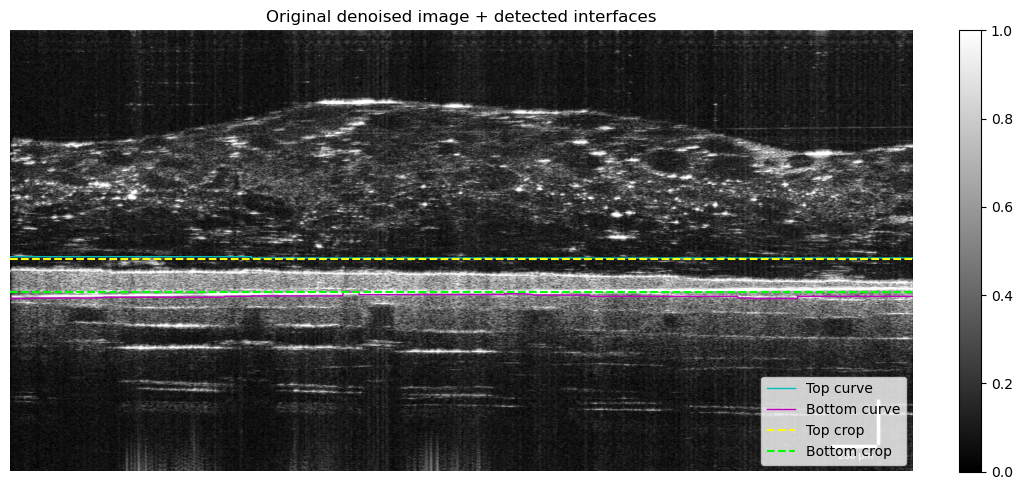

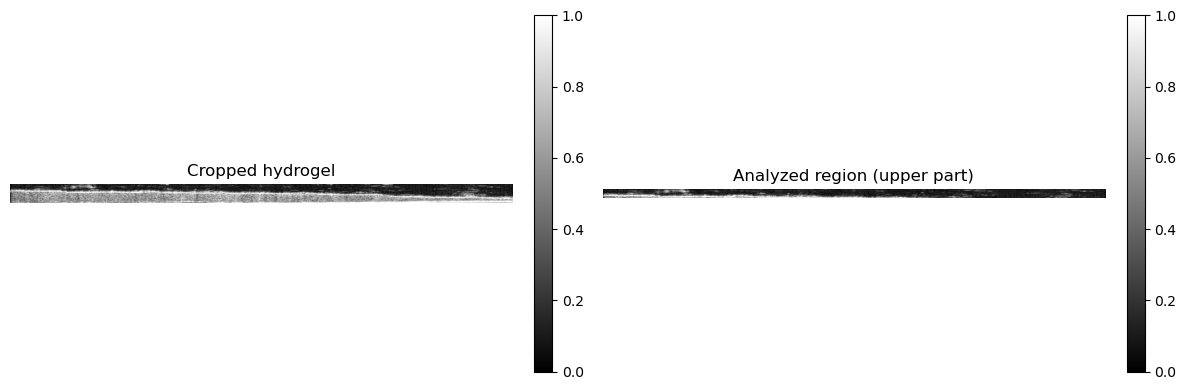

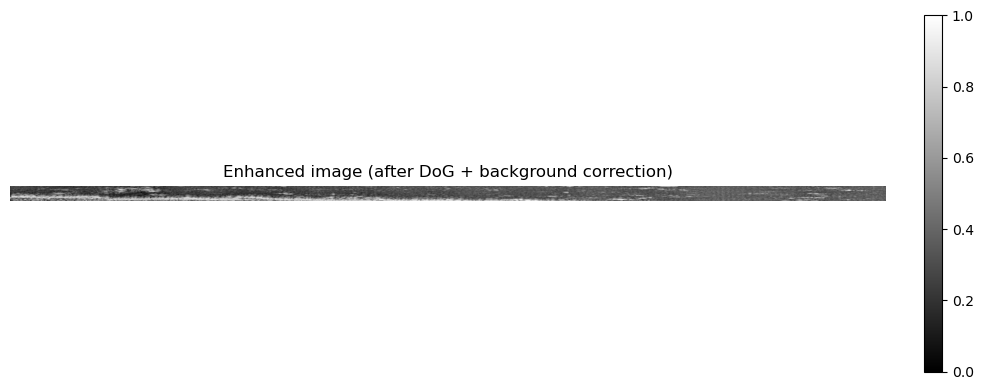

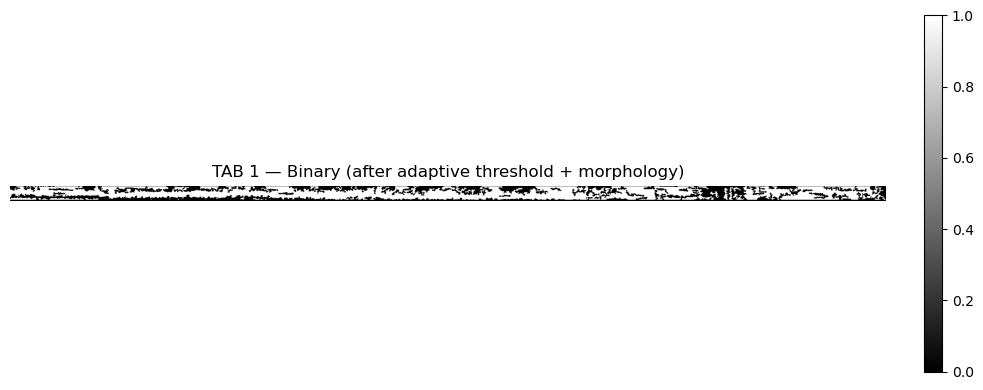

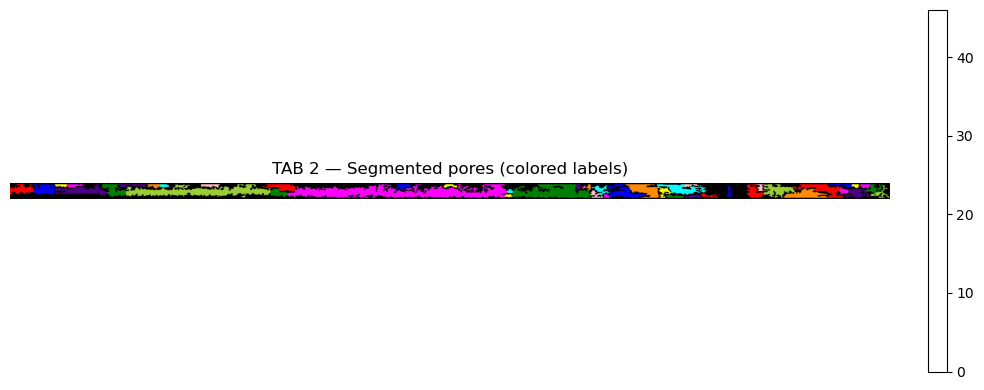

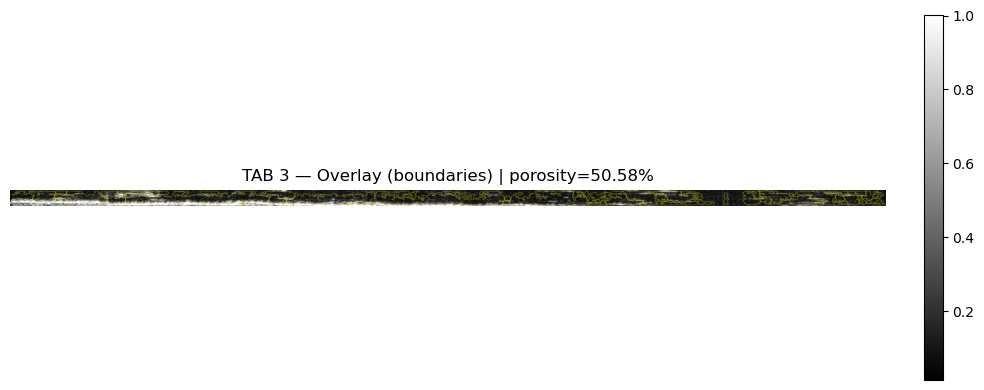


========== PARAMETER SUMMARY ==========
NLM_H_FACTOR = 1.0
TOP_ZMIN_FRAC, TOP_ZMAX_FRAC = 0.05, 0.55
BOT_ZMIN_FRAC, BOT_ZMAX_FRAC = 0.55, 0.98
TOP_PCT, BOT_PCT = 95, 5
TOP_MARGIN, BOT_MARGIN = 2, 6
SPLIT_RATIO = 0.5
SIGMA_GAUSS = 0.7
DOG_SIGMA1, DOG_SIGMA2 = 0.7, 2.0
USE_BG_SUB = True
BG_SIGMA = 20
BLOCK_SIZE = 33
OFFSET = 0.02
SE_RADIUS = 1
MIN_PORE_AREA_PX = 80
FILL_HOLES_AREA_PX = 80
USE_WATERSHED = True
DT_FG_RATIO = 0.25
DT_DILATE_ITERS = 2


In [1]:
# ============================================================
# OCT HYDROGEL PORE ANALYSIS
# Version for VARIABLE HYDROGEL CONCENTRATION
#
# Outputs:
# 1) Original / crop visualization
# 2) Enhanced image
# 3) Binary segmentation
# 4) Colored labels
# 5) Overlay on grayscale
#
# Notes:
# - Designed for OCT hydrogel images where concentration may change
# - Main tunable parameters:
#   * crop detection
#   * denoising
#   * background correction
#   * adaptive threshold
#   * morphology
#   * watershed
# ============================================================

from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, median_filter, distance_transform_edt
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import difference_of_gaussians, threshold_local
from skimage.morphology import (
    disk, binary_closing, binary_opening,
    remove_small_objects, remove_small_holes, binary_dilation
)
from skimage.segmentation import watershed, mark_boundaries
from skimage.measure import label, regionprops
from skimage.color import label2rgb


# ============================================================
# A) INPUT
# ============================================================
IN_FOLDER = Path(r"C:\Users\manue\Desktop\Master_BMED\Boite 1\Boite 1")
PATTERN = "oct_*_*_Mode2D.tif*"

files = sorted(IN_FOLDER.glob(PATTERN))
if not files:
    raise FileNotFoundError(f"No files found with pattern: {PATTERN}")

# Choose file index
FILE_INDEX = 0
f = files[FILE_INDEX]
print("Using file:", f.name)


# ============================================================
# B) PARAMETERS TO ADJUST
# ============================================================

# ---------- 1. DENOISING ----------
NLM_H_FACTOR = 1.0
# Try: 0.8, 1.0, 1.2, 1.5


# ---------- 2. INTERFACE DETECTION / CROPPING ----------
TOP_ZMIN_FRAC = 0.05
TOP_ZMAX_FRAC = 0.55

BOT_ZMIN_FRAC = 0.55
BOT_ZMAX_FRAC = 0.98

SIGMA_SMOOTH = 1.2
MEDIAN_K = 51
MAX_JUMP = 10

TOP_MARGIN = 2
BOT_MARGIN = 6

TOP_PCT = 95
BOT_PCT = 5

# Analyze only upper region? 0.5 = upper half
SPLIT_RATIO = 0.5


# ---------- 3. ENHANCEMENT ----------
SIGMA_GAUSS = 0.7
DOG_SIGMA1 = 0.7
DOG_SIGMA2 = 2.0

USE_BG_SUB = True
BG_SIGMA = 20
# Try BG_SIGMA = 15, 20, 30


# ---------- 4. ADAPTIVE THRESHOLD ----------
BLOCK_SIZE = 33     # must be odd
OFFSET = 0.02
# Try BLOCK_SIZE = 21, 33, 45, 61
# Try OFFSET = 0.00, 0.01, 0.02, 0.03, 0.05


# ---------- 5. MORPHOLOGY ----------
SE_RADIUS = 1
MIN_PORE_AREA_PX = 80
FILL_HOLES_AREA_PX = 80

PAD = 20
TOPBOT_CLEAN = 3

USE_OPENING = False   # optional extra cleaning
# If too many tiny noisy spots appear, try True


# ---------- 6. WATERSHED ----------
USE_WATERSHED = True
DT_FG_RATIO = 0.25
DT_DILATE_ITERS = 2
# Try DT_FG_RATIO = 0.15, 0.20, 0.25, 0.30


# ============================================================
# C) HELPERS
# ============================================================
def to_gray_float(img):
    if img.ndim == 2:
        return img.astype(np.float32)
    if img.ndim == 3 and img.shape[2] in (3, 4):
        rgb = img[..., :3].astype(np.float32)
        return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile01(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, (p_low, p_high))
    x = np.clip(img, lo, hi)
    return ((x - lo) / (hi - lo + 1e-8)).astype(np.float32)


def nlm_denoise(img01, h_factor=1.0):
    sigma = float(np.mean(estimate_sigma(img01, channel_axis=None)))
    out = denoise_nl_means(
        img01,
        h=h_factor * sigma,
        fast_mode=True,
        patch_size=5,
        patch_distance=6,
        channel_axis=None
    )
    return out.astype(np.float32)


def detect_line_grad(img01, zmin_frac, zmax_frac, sigma=1.2):
    H, W = img01.shape
    z0 = int(H * zmin_frac)
    z1 = int(H * zmax_frac)

    band = img01[z0:z1, :]
    band_s = gaussian_filter(band, sigma=(sigma, sigma))

    g = np.abs(np.gradient(band_s, axis=0))
    z_rel = np.argmax(g, axis=0)
    return z0 + z_rel


def clean_line(z_line, med_k=51, max_jump=10):
    if med_k % 2 == 0:
        med_k += 1

    z = median_filter(z_line.astype(np.int32), size=med_k)
    z2 = z.copy()

    for x in range(1, len(z2)):
        if abs(z2[x] - z2[x - 1]) > max_jump:
            z2[x] = z2[x - 1]

    z2 = median_filter(z2.astype(np.int32), size=med_k)
    return z2.astype(int)


def compute_pore_stats(labels_ws, pixel_size_um=None):
    props = regionprops(labels_ws)

    if len(props) == 0:
        return {
            "n_pores": 0,
            "mean_area_px": 0,
            "median_area_px": 0,
            "mean_eq_diam_px": 0,
            "median_eq_diam_px": 0,
        }

    areas = np.array([p.area for p in props], dtype=float)
    eqd = np.array([p.equivalent_diameter_area for p in props], dtype=float)

    out = {
        "n_pores": len(props),
        "mean_area_px": np.mean(areas),
        "median_area_px": np.median(areas),
        "mean_eq_diam_px": np.mean(eqd),
        "median_eq_diam_px": np.median(eqd),
    }

    if pixel_size_um is not None:
        out["mean_area_um2"] = np.mean(areas) * (pixel_size_um ** 2)
        out["median_area_um2"] = np.median(areas) * (pixel_size_um ** 2)
        out["mean_eq_diam_um"] = np.mean(eqd) * pixel_size_um
        out["median_eq_diam_um"] = np.median(eqd) * pixel_size_um

    return out


# ============================================================
# D) LOAD + NORMALIZE + DENOISE
# ============================================================
raw = tiff.imread(f)
x_gray = to_gray_float(raw)
x01 = normalize_percentile01(x_gray, 1, 99)
x_nlm = nlm_denoise(x01, h_factor=NLM_H_FACTOR)

H, W = x_nlm.shape
print("Image shape:", x_nlm.shape)


# ============================================================
# E) DETECT TOP/BOTTOM INTERFACES
# ============================================================
z_top_curve = clean_line(
    detect_line_grad(x_nlm, TOP_ZMIN_FRAC, TOP_ZMAX_FRAC, SIGMA_SMOOTH),
    MEDIAN_K,
    MAX_JUMP
)

z_bot_curve = clean_line(
    detect_line_grad(x_nlm, BOT_ZMIN_FRAC, BOT_ZMAX_FRAC, SIGMA_SMOOTH),
    MEDIAN_K,
    MAX_JUMP
)

z_top = int(np.percentile(z_top_curve, TOP_PCT)) + TOP_MARGIN
z_bot = int(np.percentile(z_bot_curve, BOT_PCT)) - BOT_MARGIN

z_top = int(np.clip(z_top, 0, H - 2))
z_bot = int(np.clip(z_bot, z_top + 50, H - 1))

x_hydrogel = x_nlm[z_top:z_bot, :]
thickness = x_hydrogel.shape[0]

z_split = int(thickness * SPLIT_RATIO)
x_upper = x_hydrogel[:z_split, :]

print("Detected top:", z_top)
print("Detected bottom:", z_bot)
print("Hydrogel thickness:", thickness, "px")
print("Upper analyzed thickness:", x_upper.shape[0], "px")


# ============================================================
# F) ENHANCEMENT
# ============================================================
roi_mask = x_upper > 0

g_img = gaussian_filter(x_upper, sigma=SIGMA_GAUSS).astype(np.float32)

dog = difference_of_gaussians(
    g_img,
    low_sigma=DOG_SIGMA1,
    high_sigma=DOG_SIGMA2
).astype(np.float32)

enh = x_upper + dog
enh = enh - enh.min()
enh = enh / (enh.max() + 1e-8)

if USE_BG_SUB:
    bg = gaussian_filter(enh, sigma=BG_SIGMA)
    enh_bp = enh - bg
    enh_bp = enh_bp - enh_bp.min()
    enh_bp = enh_bp / (enh_bp.max() + 1e-8)
else:
    enh_bp = enh.copy()


# ============================================================
# G) ADAPTIVE THRESHOLD + MORPHOLOGY
# ============================================================
# Reflect lateral padding to preserve pores near left/right borders
enh_bp_pad = np.pad(enh_bp, ((0, 0), (PAD, PAD)), mode="reflect")
roi_pad = np.pad(roi_mask, ((0, 0), (PAD, PAD)), mode="reflect")

if BLOCK_SIZE % 2 == 0:
    BLOCK_SIZE += 1

thr_map_pad = threshold_local(
    enh_bp_pad,
    block_size=BLOCK_SIZE,
    method="gaussian",
    offset=OFFSET
)

# Dark regions as pore candidates
th_pad = (enh_bp_pad < thr_map_pad) & roi_pad

se = disk(SE_RADIUS)

# Conservative morphology
morph_pad = binary_closing(th_pad, se)

if USE_OPENING:
    morph_pad = binary_opening(morph_pad, se)

morph_pad = remove_small_objects(morph_pad, min_size=MIN_PORE_AREA_PX)
morph_pad = remove_small_holes(morph_pad, area_threshold=FILL_HOLES_AREA_PX)

# Clean only top/bottom rows, not left/right
morph_pad[:TOPBOT_CLEAN, :] = False
morph_pad[-TOPBOT_CLEAN:, :] = False

# Remove lateral padding
clearimg = morph_pad[:, PAD:-PAD]


# ============================================================
# H) WATERSHED / LABELING
# ============================================================
if USE_WATERSHED:
    dt = distance_transform_edt(clearimg)

    if dt.max() > 0:
        sure_fg = dt > (DT_FG_RATIO * dt.max())
    else:
        sure_fg = clearimg.copy()

    sure_bg = clearimg.copy()
    for _ in range(DT_DILATE_ITERS):
        sure_bg = binary_dilation(sure_bg, se)

    unknown = sure_bg & (~sure_fg)

    markers = label(sure_fg).astype(np.int32)
    markers[unknown] = 0

    labels_ws = watershed(-dt, markers, mask=clearimg)
else:
    labels_ws = label(clearimg)

pores_binary = labels_ws > 0
porosity = 100.0 * pores_binary.sum() / (roi_mask.sum() + 1e-8)

stats = compute_pore_stats(labels_ws, pixel_size_um=None)

print("\n========== RESULTS ==========")
print(f"Porosity (%): {porosity:.2f}")
print(f"Number of pores: {stats['n_pores']}")
print(f"Mean area (px²): {stats['mean_area_px']:.2f}")
print(f"Median area (px²): {stats['median_area_px']:.2f}")
print(f"Mean equiv. diameter (px): {stats['mean_eq_diam_px']:.2f}")
print(f"Median equiv. diameter (px): {stats['median_eq_diam_px']:.2f}")


# ============================================================
# I) VISUALIZATION
# ============================================================

# ---------- Figure 1: original + detected interfaces ----------
plt.figure(figsize=(12, 5))
ax = plt.gca()
im = ax.imshow(x_nlm, cmap="gray")
ax.plot(np.arange(W), z_top_curve, 'c-', lw=1, label='Top curve')
ax.plot(np.arange(W), z_bot_curve, 'm-', lw=1, label='Bottom curve')
ax.axhline(z_top, color='yellow', ls='--', lw=1.5, label='Top crop')
ax.axhline(z_bot, color='lime', ls='--', lw=1.5, label='Bottom crop')
ax.set_title("Original denoised image + detected interfaces")
ax.axis("off")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


# ---------- Figure 2: cropped hydrogel + analyzed upper part ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(x_hydrogel, cmap="gray")
axes[0].set_title("Cropped hydrogel")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(x_upper, cmap="gray")
axes[1].set_title("Analyzed region (upper part)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ---------- Figure 3: enhanced image ----------
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(enh_bp, cmap="gray")
ax.set_title("Enhanced image (after DoG + background correction)")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


# ---------- Figure 4: binary ----------
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(clearimg.astype(float), cmap="gray")
ax.set_title("TAB 1 — Binary (after adaptive threshold + morphology)")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


# ---------- Figure 5: colored labels ----------
seg_rgb = label2rgb(labels_ws, image=None, bg_label=0)

plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.imshow(seg_rgb)
ax.set_title("TAB 2 — Segmented pores (colored labels)")
ax.axis("off")

mappable = ax.imshow(labels_ws.astype(float), cmap="nipy_spectral", alpha=0.0)
plt.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ---------- Figure 6: overlay ----------
valid_pixels = x_upper[x_upper > 0]
if valid_pixels.size > 0:
    vmin, vmax = np.percentile(valid_pixels, (1, 99))
else:
    vmin, vmax = 0, 1

overlay = mark_boundaries(
    np.clip(x_upper, 0, 1),
    labels_ws,
    color=(1, 1, 0),
    mode="outer"
)

plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(x_upper, cmap="gray", vmin=vmin, vmax=vmax)
ax.imshow(overlay, alpha=0.6)
ax.set_title(f"TAB 3 — Overlay (boundaries) | porosity={porosity:.2f}%")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


# ============================================================
# J) OPTIONAL: SHOW PARAMETER SUMMARY
# ============================================================
print("\n========== PARAMETER SUMMARY ==========")
print(f"NLM_H_FACTOR = {NLM_H_FACTOR}")
print(f"TOP_ZMIN_FRAC, TOP_ZMAX_FRAC = {TOP_ZMIN_FRAC}, {TOP_ZMAX_FRAC}")
print(f"BOT_ZMIN_FRAC, BOT_ZMAX_FRAC = {BOT_ZMIN_FRAC}, {BOT_ZMAX_FRAC}")
print(f"TOP_PCT, BOT_PCT = {TOP_PCT}, {BOT_PCT}")
print(f"TOP_MARGIN, BOT_MARGIN = {TOP_MARGIN}, {BOT_MARGIN}")
print(f"SPLIT_RATIO = {SPLIT_RATIO}")
print(f"SIGMA_GAUSS = {SIGMA_GAUSS}")
print(f"DOG_SIGMA1, DOG_SIGMA2 = {DOG_SIGMA1}, {DOG_SIGMA2}")
print(f"USE_BG_SUB = {USE_BG_SUB}")
print(f"BG_SIGMA = {BG_SIGMA}")
print(f"BLOCK_SIZE = {BLOCK_SIZE}")
print(f"OFFSET = {OFFSET}")
print(f"SE_RADIUS = {SE_RADIUS}")
print(f"MIN_PORE_AREA_PX = {MIN_PORE_AREA_PX}")
print(f"FILL_HOLES_AREA_PX = {FILL_HOLES_AREA_PX}")
print(f"USE_WATERSHED = {USE_WATERSHED}")
print(f"DT_FG_RATIO = {DT_FG_RATIO}")
print(f"DT_DILATE_ITERS = {DT_DILATE_ITERS}")


Using file: oct_10_0021_Mode2D.tiff
Image shape: (1024, 2095)
Detected top: 234
Chosen bottom: 384
Hydrogel thickness used: 150 px
Upper analyzed thickness: 75 px

========== RESULTS ==========
Porosity (%): 42.22
Number of pores: 182
Mean area (px²): 363.71
Median area (px²): 145.50
Mean equiv. diameter (px): 17.23
Median equiv. diameter (px): 13.61


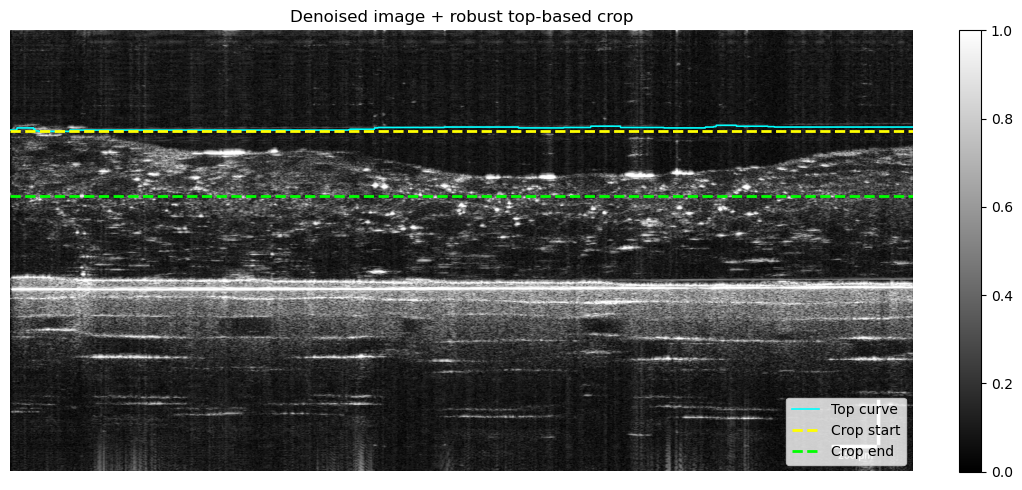

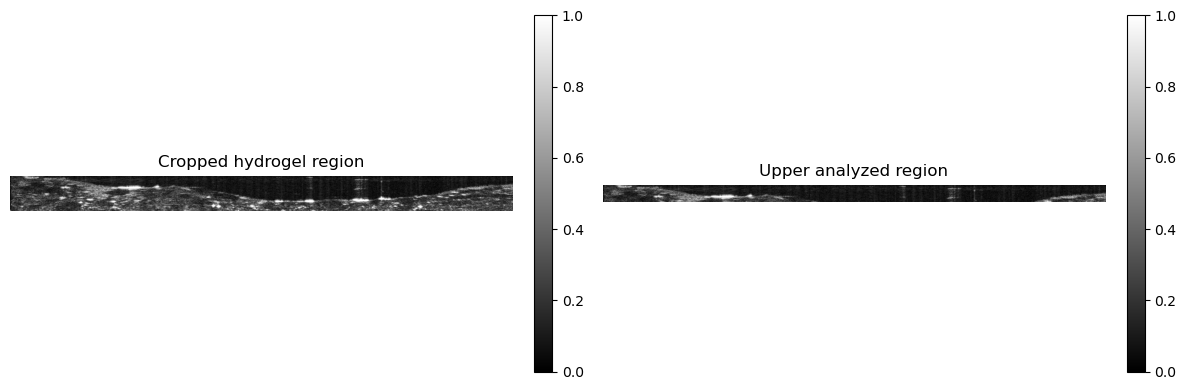

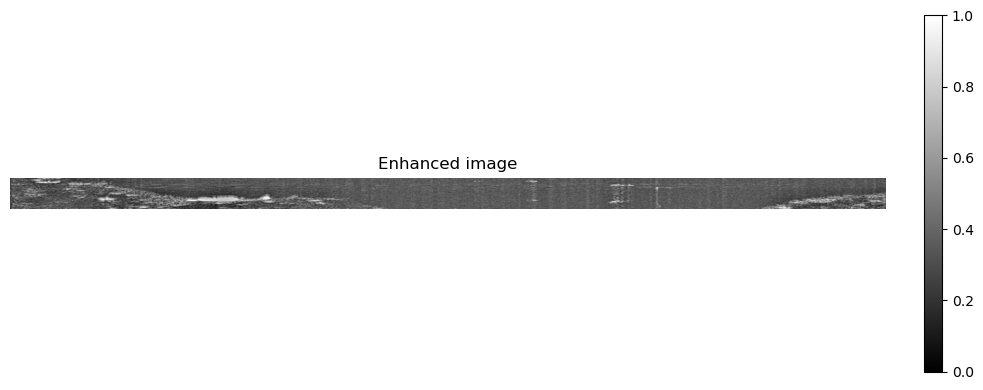

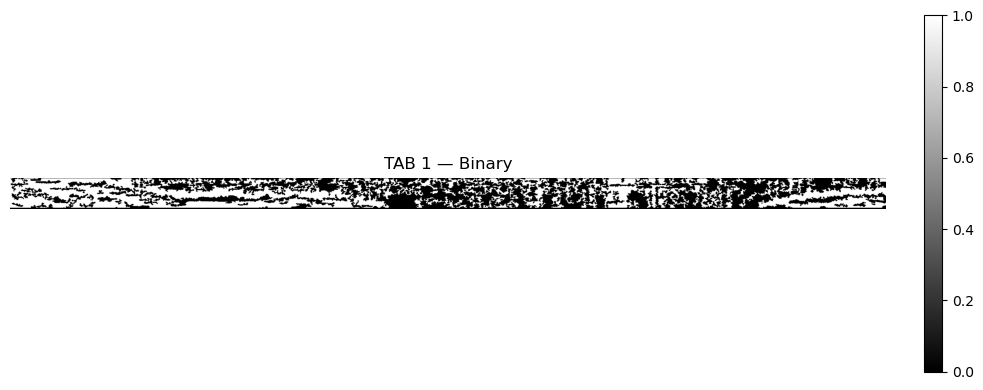

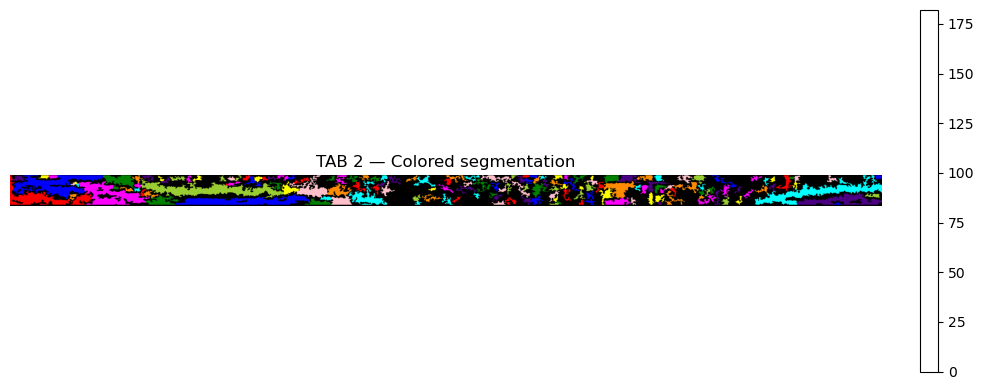

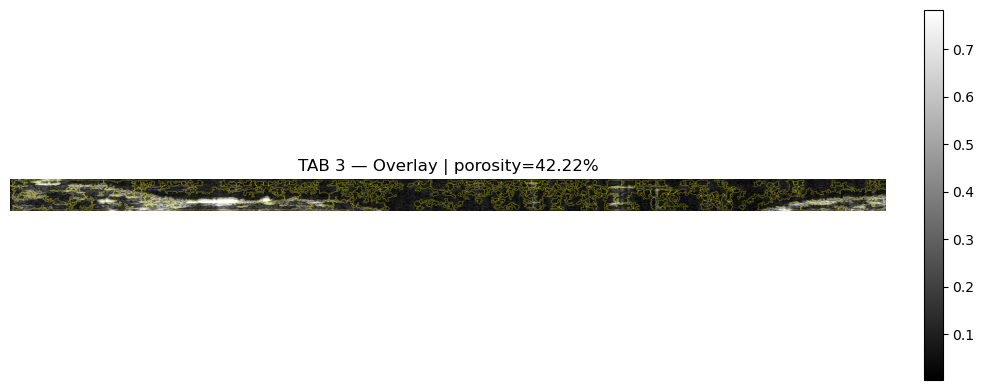

In [4]:
# ============================================================
# OCT HYDROGEL PORE ANALYSIS
# ROBUST VERSION: crop based mainly on TOP SURFACE
# Better when bottom interface is ambiguous / unstable
# ============================================================

from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, median_filter, distance_transform_edt
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import difference_of_gaussians, threshold_local
from skimage.morphology import (
    disk, binary_closing, binary_opening,
    remove_small_objects, remove_small_holes, binary_dilation
)
from skimage.segmentation import watershed, mark_boundaries
from skimage.measure import label, regionprops
from skimage.color import label2rgb


# ============================================================
# A) INPUT
# ============================================================
IN_FOLDER = Path(r"C:\Users\manue\Desktop\Master_BMED\Boite 1\Boite 1")
PATTERN = "oct_*_*_Mode2D.tif*"

files = sorted(IN_FOLDER.glob(PATTERN))
if not files:
    raise FileNotFoundError(f"No files found with pattern: {PATTERN}")

FILE_INDEX = 2
f = files[FILE_INDEX]
print("Using file:", f.name)


# ============================================================
# B) PARAMETERS
# ============================================================

# ---------- DENOISING ----------
NLM_H_FACTOR = 1.0

# ---------- TOP SURFACE DETECTION ----------
TOP_ZMIN_FRAC = 0.03
TOP_ZMAX_FRAC = 0.30
SIGMA_SMOOTH = 1.2
MEDIAN_K = 51
MAX_JUMP = 10

TOP_PCT = 75          # more robust than 95 here
TOP_MARGIN = 3        # start a bit below detected surface

# ---------- ROBUST CROP FROM TOP ----------
USE_FIXED_THICKNESS = True
HYDROGEL_THICKNESS_PX = 150   # <<< AJUSTAR según imagen
# prueba: 120, 140, 160, 180

# analyze only upper part of cropped hydrogel
SPLIT_RATIO = 0.5

# ---------- ENHANCEMENT ----------
SIGMA_GAUSS = 0.7
DOG_SIGMA1 = 0.7
DOG_SIGMA2 = 2.0

USE_BG_SUB = True
BG_SIGMA = 20

# ---------- THRESHOLD ----------
BLOCK_SIZE = 45
OFFSET = 0.02

# ---------- MORPHOLOGY ----------
SE_RADIUS = 1
MIN_PORE_AREA_PX = 80
FILL_HOLES_AREA_PX = 80
PAD = 20
TOPBOT_CLEAN = 3
USE_OPENING = False

# ---------- WATERSHED ----------
USE_WATERSHED = True
DT_FG_RATIO = 0.25
DT_DILATE_ITERS = 2


# ============================================================
# C) HELPERS
# ============================================================
def to_gray_float(img):
    if img.ndim == 2:
        return img.astype(np.float32)
    if img.ndim == 3 and img.shape[2] in (3, 4):
        rgb = img[..., :3].astype(np.float32)
        return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile01(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, (p_low, p_high))
    x = np.clip(img, lo, hi)
    return ((x - lo) / (hi - lo + 1e-8)).astype(np.float32)


def nlm_denoise(img01, h_factor=1.0):
    sigma = float(np.mean(estimate_sigma(img01, channel_axis=None)))
    out = denoise_nl_means(
        img01,
        h=h_factor * sigma,
        fast_mode=True,
        patch_size=5,
        patch_distance=6,
        channel_axis=None
    )
    return out.astype(np.float32)


def detect_line_grad(img01, zmin_frac, zmax_frac, sigma=1.2):
    H, W = img01.shape
    z0 = int(H * zmin_frac)
    z1 = int(H * zmax_frac)

    band = img01[z0:z1, :]
    band_s = gaussian_filter(band, sigma=(sigma, sigma))
    g = np.abs(np.gradient(band_s, axis=0))
    z_rel = np.argmax(g, axis=0)
    return z0 + z_rel


def clean_line(z_line, med_k=51, max_jump=10):
    if med_k % 2 == 0:
        med_k += 1

    z = median_filter(z_line.astype(np.int32), size=med_k)
    z2 = z.copy()

    for x in range(1, len(z2)):
        if abs(z2[x] - z2[x - 1]) > max_jump:
            z2[x] = z2[x - 1]

    z2 = median_filter(z2.astype(np.int32), size=med_k)
    return z2.astype(int)


def compute_pore_stats(labels_ws):
    props = regionprops(labels_ws)

    if len(props) == 0:
        return {
            "n_pores": 0,
            "mean_area_px": 0,
            "median_area_px": 0,
            "mean_eq_diam_px": 0,
            "median_eq_diam_px": 0,
        }

    areas = np.array([p.area for p in props], dtype=float)
    eqd = np.array([p.equivalent_diameter_area for p in props], dtype=float)

    return {
        "n_pores": len(props),
        "mean_area_px": np.mean(areas),
        "median_area_px": np.median(areas),
        "mean_eq_diam_px": np.mean(eqd),
        "median_eq_diam_px": np.median(eqd),
    }


# ============================================================
# D) LOAD + NORMALIZE + DENOISE
# ============================================================
raw = tiff.imread(f)
x_gray = to_gray_float(raw)
x01 = normalize_percentile01(x_gray, 1, 99)
x_nlm = nlm_denoise(x01, h_factor=NLM_H_FACTOR)

H, W = x_nlm.shape
print("Image shape:", x_nlm.shape)


# ============================================================
# E) ROBUST TOP-BASED CROP
# ============================================================
z_top_curve = clean_line(
    detect_line_grad(x_nlm, TOP_ZMIN_FRAC, TOP_ZMAX_FRAC, SIGMA_SMOOTH),
    MEDIAN_K,
    MAX_JUMP
)

# more conservative robust top
z_top = int(np.percentile(z_top_curve, TOP_PCT)) + TOP_MARGIN
z_top = int(np.clip(z_top, 0, H - 2))

if USE_FIXED_THICKNESS:
    z_bot = z_top + HYDROGEL_THICKNESS_PX
else:
    z_bot = int(H * 0.55)  # fallback only

z_bot = int(np.clip(z_bot, z_top + 50, H - 1))

x_hydrogel = x_nlm[z_top:z_bot, :]
thickness = x_hydrogel.shape[0]

z_split = int(thickness * SPLIT_RATIO)
x_upper = x_hydrogel[:z_split, :]

print("Detected top:", z_top)
print("Chosen bottom:", z_bot)
print("Hydrogel thickness used:", thickness, "px")
print("Upper analyzed thickness:", x_upper.shape[0], "px")


# ============================================================
# F) ENHANCEMENT
# ============================================================
roi_mask = x_upper > 0

g_img = gaussian_filter(x_upper, sigma=SIGMA_GAUSS).astype(np.float32)

dog = difference_of_gaussians(
    g_img,
    low_sigma=DOG_SIGMA1,
    high_sigma=DOG_SIGMA2
).astype(np.float32)

enh = x_upper + dog
enh = enh - enh.min()
enh = enh / (enh.max() + 1e-8)

if USE_BG_SUB:
    bg = gaussian_filter(enh, sigma=BG_SIGMA)
    enh_bp = enh - bg
    enh_bp = enh_bp - enh_bp.min()
    enh_bp = enh_bp / (enh_bp.max() + 1e-8)
else:
    enh_bp = enh.copy()


# ============================================================
# G) THRESHOLD + MORPHOLOGY
# ============================================================
enh_bp_pad = np.pad(enh_bp, ((0, 0), (PAD, PAD)), mode="reflect")
roi_pad = np.pad(roi_mask, ((0, 0), (PAD, PAD)), mode="reflect")

if BLOCK_SIZE % 2 == 0:
    BLOCK_SIZE += 1

thr_map_pad = threshold_local(
    enh_bp_pad,
    block_size=BLOCK_SIZE,
    method="gaussian",
    offset=OFFSET
)

th_pad = (enh_bp_pad < thr_map_pad) & roi_pad

se = disk(SE_RADIUS)

morph_pad = binary_closing(th_pad, se)

if USE_OPENING:
    morph_pad = binary_opening(morph_pad, se)

morph_pad = remove_small_objects(morph_pad, min_size=MIN_PORE_AREA_PX)
morph_pad = remove_small_holes(morph_pad, area_threshold=FILL_HOLES_AREA_PX)

morph_pad[:TOPBOT_CLEAN, :] = False
morph_pad[-TOPBOT_CLEAN:, :] = False

clearimg = morph_pad[:, PAD:-PAD]


# ============================================================
# H) WATERSHED
# ============================================================
if USE_WATERSHED:
    dt = distance_transform_edt(clearimg)

    if dt.max() > 0:
        sure_fg = dt > (DT_FG_RATIO * dt.max())
    else:
        sure_fg = clearimg.copy()

    sure_bg = clearimg.copy()
    for _ in range(DT_DILATE_ITERS):
        sure_bg = binary_dilation(sure_bg, se)

    unknown = sure_bg & (~sure_fg)

    markers = label(sure_fg).astype(np.int32)
    markers[unknown] = 0

    labels_ws = watershed(-dt, markers, mask=clearimg)
else:
    labels_ws = label(clearimg)

pores_binary = labels_ws > 0
porosity = 100.0 * pores_binary.sum() / (roi_mask.sum() + 1e-8)

stats = compute_pore_stats(labels_ws)

print("\n========== RESULTS ==========")
print(f"Porosity (%): {porosity:.2f}")
print(f"Number of pores: {stats['n_pores']}")
print(f"Mean area (px²): {stats['mean_area_px']:.2f}")
print(f"Median area (px²): {stats['median_area_px']:.2f}")
print(f"Mean equiv. diameter (px): {stats['mean_eq_diam_px']:.2f}")
print(f"Median equiv. diameter (px): {stats['median_eq_diam_px']:.2f}")


# ============================================================
# I) VISUALIZATION
# ============================================================

# 1) original + top line + crop
plt.figure(figsize=(12, 5))
ax = plt.gca()
im = ax.imshow(x_nlm, cmap="gray")
ax.plot(np.arange(W), z_top_curve, color='cyan', lw=1.2, label='Top curve')
ax.axhline(z_top, color='yellow', ls='--', lw=2, label='Crop start')
ax.axhline(z_bot, color='lime', ls='--', lw=2, label='Crop end')
ax.set_title("Denoised image + robust top-based crop")
ax.axis("off")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 2) crop + analyzed upper part
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(x_hydrogel, cmap="gray")
axes[0].set_title("Cropped hydrogel region")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(x_upper, cmap="gray")
axes[1].set_title("Upper analyzed region")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# 3) enhanced
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(enh_bp, cmap="gray")
ax.set_title("Enhanced image")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 4) binary
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(clearimg.astype(float), cmap="gray")
ax.set_title("TAB 1 — Binary")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 5) labels
seg_rgb = label2rgb(labels_ws, image=None, bg_label=0)

plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.imshow(seg_rgb)
ax.set_title("TAB 2 — Colored segmentation")
ax.axis("off")
mappable = ax.imshow(labels_ws.astype(float), cmap="nipy_spectral", alpha=0.0)
plt.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 6) overlay
valid_pixels = x_upper[x_upper > 0]
if valid_pixels.size > 0:
    vmin, vmax = np.percentile(valid_pixels, (1, 99))
else:
    vmin, vmax = 0, 1

overlay = mark_boundaries(
    np.clip(x_upper, 0, 1),
    labels_ws,
    color=(1, 1, 0),
    mode="outer"
)

plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(x_upper, cmap="gray", vmin=vmin, vmax=vmax)
ax.imshow(overlay, alpha=0.6)
ax.set_title(f"TAB 3 — Overlay | porosity={porosity:.2f}%")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Using file: oct_10_0019_Mode2D.tiff

========== RESULTS ==========
Porosity (%): 52.04
Number of pores: 3
Mean area (px²): 27254.67
Median area (px²): 8641.00


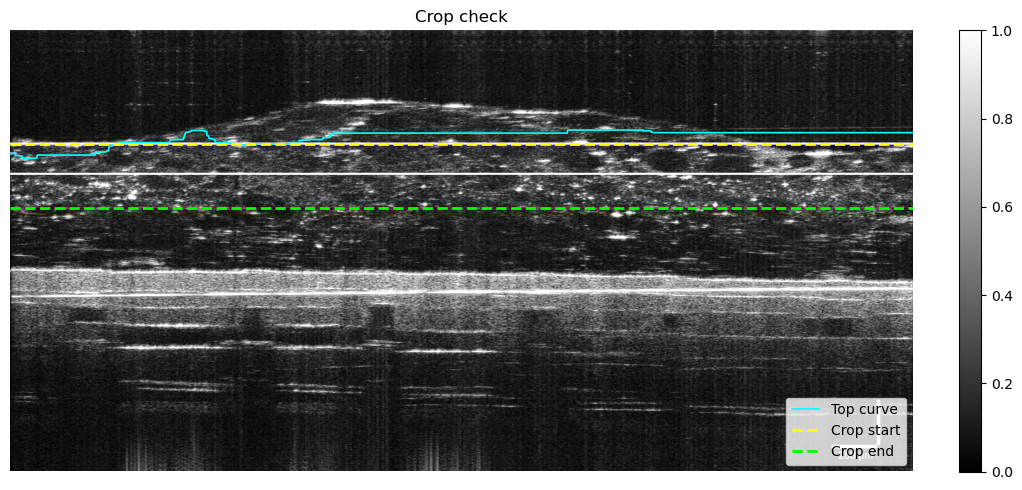

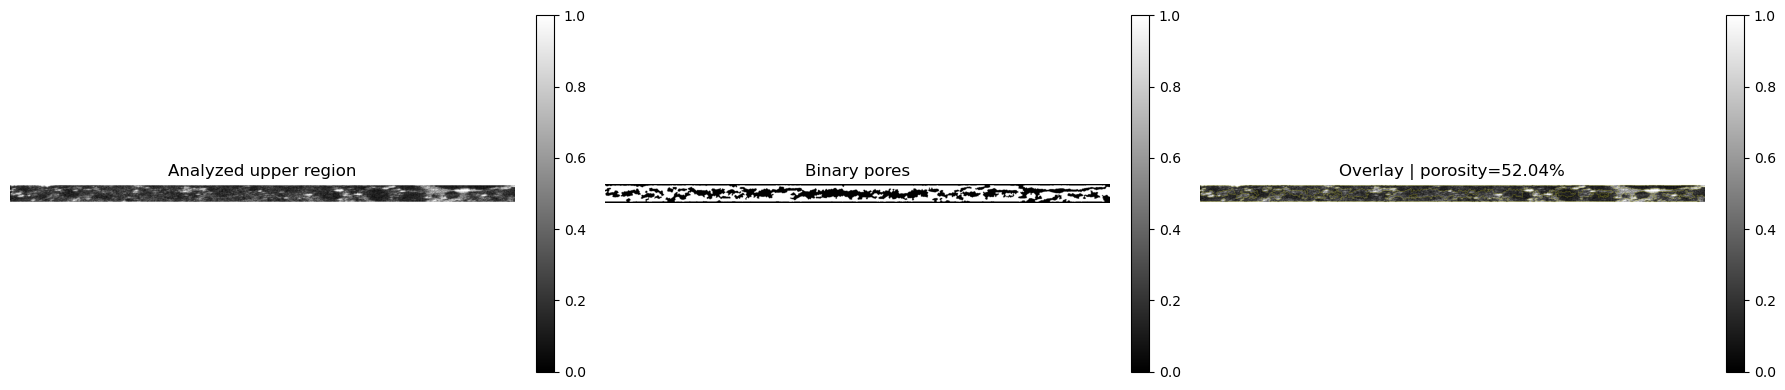

In [3]:
# ============================================================
# SEGMENTATION TUNED FOR "ONLY LARGE DARK PORES"
# More similar to manual contouring in Paint
# ============================================================

from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, median_filter
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import threshold_local
from skimage.morphology import (
    disk, binary_closing, binary_opening,
    remove_small_objects, remove_small_holes
)
from skimage.measure import label, regionprops
from skimage.segmentation import mark_boundaries


# ============================================================
# A) INPUT
# ============================================================
IN_FOLDER = Path(r"C:\Users\manue\Desktop\Master_BMED\Boite 1\Boite 1")
PATTERN = "oct_*_*_Mode2D.tif*"

files = sorted(IN_FOLDER.glob(PATTERN))
if not files:
    raise FileNotFoundError(f"No files found with pattern: {PATTERN}")

FILE_INDEX = 0
f = files[FILE_INDEX]
print("Using file:", f.name)


# ============================================================
# B) PARAMETERS
# ============================================================

# ----- denoise -----
NLM_H_FACTOR = 1.0

# ----- crop already acceptable -----
TOP_ZMIN_FRAC = 0.03
TOP_ZMAX_FRAC = 0.30
SIGMA_SMOOTH = 1.2
MEDIAN_K = 51
MAX_JUMP = 10
TOP_PCT = 75
TOP_MARGIN = 3
HYDROGEL_THICKNESS_PX = 150
SPLIT_RATIO = 0.5

# ----- segmentation tuned to large dark pores -----
SIGMA_GAUSS = 1.4        # more smoothing than before
BLOCK_SIZE = 61          # larger local window
OFFSET = 0.04            # more restrictive
SE_RADIUS = 2
MIN_PORE_AREA_PX = 1200  # key parameter
FILL_HOLES_AREA_PX = 150
USE_OPENING = True

# optional manual depth trimming inside x_upper
TRIM_TOP_ROWS = 5
TRIM_BOTTOM_ROWS = 5


# ============================================================
# C) HELPERS
# ============================================================
def to_gray_float(img):
    if img.ndim == 2:
        return img.astype(np.float32)
    if img.ndim == 3 and img.shape[2] in (3, 4):
        rgb = img[..., :3].astype(np.float32)
        return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile01(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, (p_low, p_high))
    x = np.clip(img, lo, hi)
    return ((x - lo) / (hi - lo + 1e-8)).astype(np.float32)


def nlm_denoise(img01, h_factor=1.0):
    sigma = float(np.mean(estimate_sigma(img01, channel_axis=None)))
    out = denoise_nl_means(
        img01,
        h=h_factor * sigma,
        fast_mode=True,
        patch_size=5,
        patch_distance=6,
        channel_axis=None
    )
    return out.astype(np.float32)


def detect_line_grad(img01, zmin_frac, zmax_frac, sigma=1.2):
    H, W = img01.shape
    z0 = int(H * zmin_frac)
    z1 = int(H * zmax_frac)
    band = img01[z0:z1, :]
    band_s = gaussian_filter(band, sigma=(sigma, sigma))
    g = np.abs(np.gradient(band_s, axis=0))
    z_rel = np.argmax(g, axis=0)
    return z0 + z_rel


def clean_line(z_line, med_k=51, max_jump=10):
    if med_k % 2 == 0:
        med_k += 1
    z = median_filter(z_line.astype(np.int32), size=med_k)
    z2 = z.copy()
    for x in range(1, len(z2)):
        if abs(z2[x] - z2[x - 1]) > max_jump:
            z2[x] = z2[x - 1]
    z2 = median_filter(z2.astype(np.int32), size=med_k)
    return z2.astype(int)


def compute_stats(mask):
    labels = label(mask)
    props = regionprops(labels)

    if len(props) == 0:
        return labels, 0, 0, 0

    areas = np.array([p.area for p in props], dtype=float)
    return labels, len(props), float(np.mean(areas)), float(np.median(areas))


# ============================================================
# D) LOAD + CROP
# ============================================================
raw = tiff.imread(f)
x_gray = to_gray_float(raw)
x01 = normalize_percentile01(x_gray, 1, 99)
x_nlm = nlm_denoise(x01, h_factor=NLM_H_FACTOR)

H, W = x_nlm.shape

z_top_curve = clean_line(
    detect_line_grad(x_nlm, TOP_ZMIN_FRAC, TOP_ZMAX_FRAC, SIGMA_SMOOTH),
    MEDIAN_K,
    MAX_JUMP
)

z_top = int(np.percentile(z_top_curve, TOP_PCT)) + TOP_MARGIN
z_top = int(np.clip(z_top, 0, H - 2))
z_bot = int(np.clip(z_top + HYDROGEL_THICKNESS_PX, z_top + 50, H - 1))

x_hydrogel = x_nlm[z_top:z_bot, :]
thickness = x_hydrogel.shape[0]

z_split = int(thickness * SPLIT_RATIO)
x_upper = x_hydrogel[:z_split, :]

if TRIM_TOP_ROWS > 0:
    x_upper[:TRIM_TOP_ROWS, :] = 1.0
if TRIM_BOTTOM_ROWS > 0:
    x_upper[-TRIM_BOTTOM_ROWS:, :] = 1.0

roi_mask = np.ones_like(x_upper, dtype=bool)


# ============================================================
# E) SEGMENT ONLY DARK LARGE REGIONS
# ============================================================
smooth = gaussian_filter(x_upper, sigma=SIGMA_GAUSS)

if BLOCK_SIZE % 2 == 0:
    BLOCK_SIZE += 1

thr = threshold_local(
    smooth,
    block_size=BLOCK_SIZE,
    method="gaussian",
    offset=OFFSET
)

# dark candidates
pores0 = (smooth < thr) & roi_mask

# morphology
se = disk(SE_RADIUS)
pores1 = binary_closing(pores0, se)

if USE_OPENING:
    pores1 = binary_opening(pores1, se)

pores2 = remove_small_objects(pores1, min_size=MIN_PORE_AREA_PX)
pores3 = remove_small_holes(pores2, area_threshold=FILL_HOLES_AREA_PX)

labels_ws, n_pores, mean_area, median_area = compute_stats(pores3)

porosity = 100.0 * pores3.sum() / pores3.size

print("\n========== RESULTS ==========")
print(f"Porosity (%): {porosity:.2f}")
print(f"Number of pores: {n_pores}")
print(f"Mean area (px²): {mean_area:.2f}")
print(f"Median area (px²): {median_area:.2f}")


# ============================================================
# F) VISUALIZATION
# ============================================================
plt.figure(figsize=(12, 5))
ax = plt.gca()
im = ax.imshow(x_nlm, cmap="gray")
ax.plot(np.arange(W), z_top_curve, color='cyan', lw=1.2, label='Top curve')
ax.axhline(z_top, color='yellow', ls='--', lw=2, label='Crop start')
ax.axhline(z_bot, color='lime', ls='--', lw=2, label='Crop end')
ax.set_title("Crop check")
ax.axis("off")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

im0 = axes[0].imshow(x_upper, cmap="gray")
axes[0].set_title("Analyzed upper region")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(pores3.astype(float), cmap="gray")
axes[1].set_title("Binary pores")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

overlay = mark_boundaries(np.clip(x_upper, 0, 1), labels_ws, color=(1, 1, 0), mode="outer")
im2 = axes[2].imshow(x_upper, cmap="gray")
axes[2].imshow(overlay, alpha=0.7)
axes[2].set_title(f"Overlay | porosity={porosity:.2f}%")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Using file: oct_10_0019_Mode2D.tiff

========== IMAGE QUALITY ==========
Mean signal intensity: 0.3778
Std signal intensity: 0.2960
Mean background intensity: 0.1910
Std background intensity: 0.1391
SNR (global): 2.72
SNR (local): 1.28
CNR: 0.57
Quality assessment: Borderline

========== SEGMENTATION RESULTS ==========
Porosity (%): 52.04
Number of pores: 3
Mean area (px²): 27254.67
Median area (px²): 8641.00


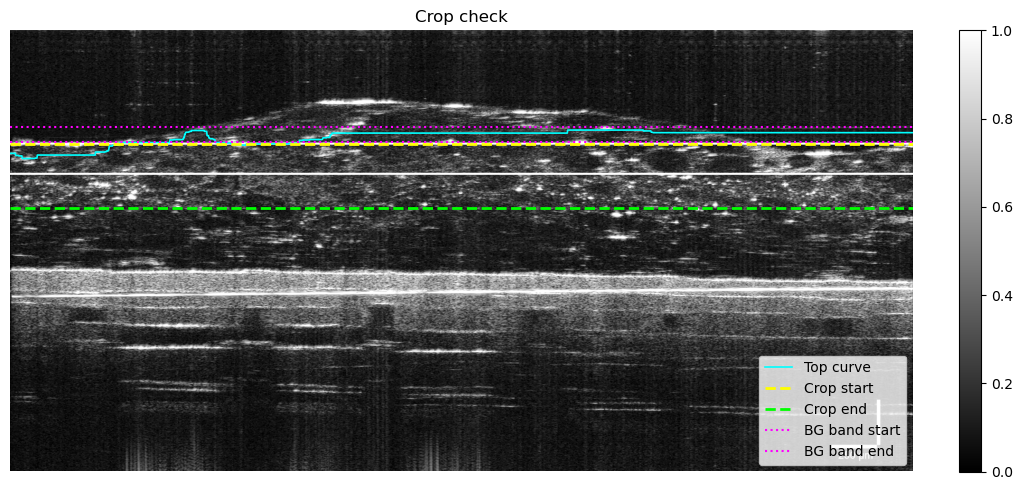

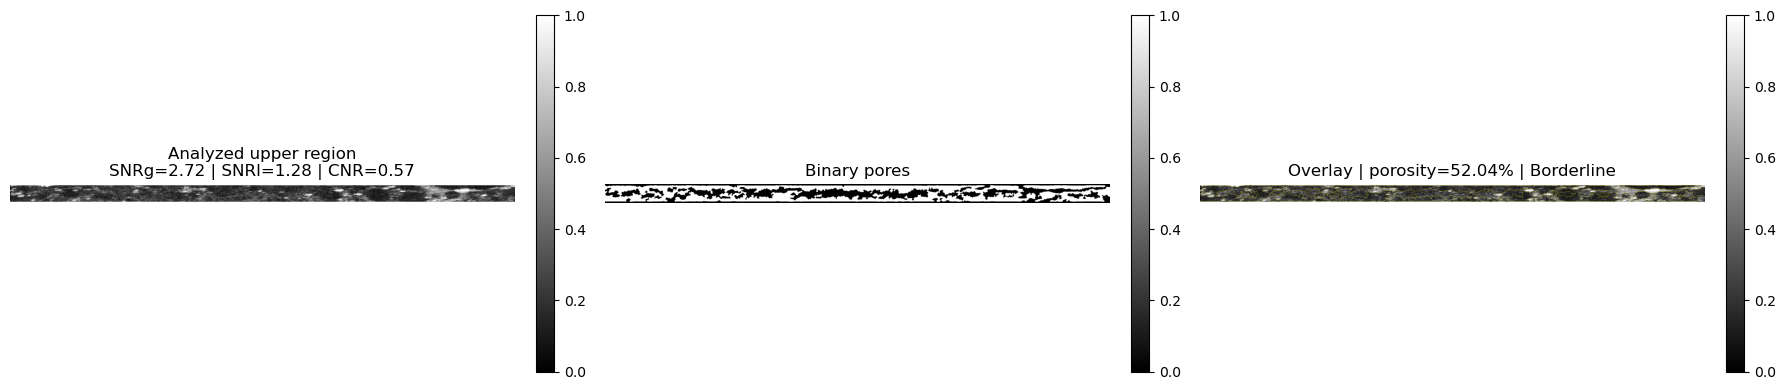


Saved: segmentation_quality_metrics.csv


In [1]:
# ============================================================
# SEGMENTATION TUNED FOR "ONLY LARGE DARK PORES"
# More similar to manual contouring in Paint
# + IMAGE QUALITY METRICS: SNR / CNR
# ============================================================

from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, median_filter
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import threshold_local
from skimage.morphology import (
    disk, binary_closing, binary_opening,
    remove_small_objects, remove_small_holes
)
from skimage.measure import label, regionprops
from skimage.segmentation import mark_boundaries


# ============================================================
# A) INPUT
# ============================================================
IN_FOLDER = Path(r"C:\Users\manue\Desktop\Master_BMED\Boite 1\Boite 1")
PATTERN = "oct_*_*_Mode2D.tif*"

files = sorted(IN_FOLDER.glob(PATTERN))
if not files:
    raise FileNotFoundError(f"No files found with pattern: {PATTERN}")

FILE_INDEX = 0
f = files[FILE_INDEX]
print("Using file:", f.name)


# ============================================================
# B) PARAMETERS
# ============================================================

# ----- denoise -----
NLM_H_FACTOR = 1.0

# ----- crop already acceptable -----
TOP_ZMIN_FRAC = 0.03
TOP_ZMAX_FRAC = 0.30
SIGMA_SMOOTH = 1.2
MEDIAN_K = 51
MAX_JUMP = 10
TOP_PCT = 75
TOP_MARGIN = 3
HYDROGEL_THICKNESS_PX = 150
SPLIT_RATIO = 0.5

# ----- segmentation tuned to large dark pores -----
SIGMA_GAUSS = 1.4
BLOCK_SIZE = 61
OFFSET = 0.04
SE_RADIUS = 2
MIN_PORE_AREA_PX = 1200
FILL_HOLES_AREA_PX = 150
USE_OPENING = True

# optional manual depth trimming inside x_upper
TRIM_TOP_ROWS = 5
TRIM_BOTTOM_ROWS = 5


# ============================================================
# C) HELPERS
# ============================================================
def to_gray_float(img):
    if img.ndim == 2:
        return img.astype(np.float32)
    if img.ndim == 3 and img.shape[2] in (3, 4):
        rgb = img[..., :3].astype(np.float32)
        return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile01(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, (p_low, p_high))
    x = np.clip(img, lo, hi)
    return ((x - lo) / (hi - lo + 1e-8)).astype(np.float32)


def nlm_denoise(img01, h_factor=1.0):
    sigma = float(np.mean(estimate_sigma(img01, channel_axis=None)))
    out = denoise_nl_means(
        img01,
        h=h_factor * sigma,
        fast_mode=True,
        patch_size=5,
        patch_distance=6,
        channel_axis=None
    )
    return out.astype(np.float32)


def detect_line_grad(img01, zmin_frac, zmax_frac, sigma=1.2):
    H, W = img01.shape
    z0 = int(H * zmin_frac)
    z1 = int(H * zmax_frac)
    band = img01[z0:z1, :]
    band_s = gaussian_filter(band, sigma=(sigma, sigma))
    g = np.abs(np.gradient(band_s, axis=0))
    z_rel = np.argmax(g, axis=0)
    return z0 + z_rel


def clean_line(z_line, med_k=51, max_jump=10):
    if med_k % 2 == 0:
        med_k += 1
    z = median_filter(z_line.astype(np.int32), size=med_k)
    z2 = z.copy()
    for x in range(1, len(z2)):
        if abs(z2[x] - z2[x - 1]) > max_jump:
            z2[x] = z2[x - 1]
    z2 = median_filter(z2.astype(np.int32), size=med_k)
    return z2.astype(int)


def compute_stats(mask):
    labels = label(mask)
    props = regionprops(labels)

    if len(props) == 0:
        return labels, 0, 0, 0

    areas = np.array([p.area for p in props], dtype=float)
    return labels, len(props), float(np.mean(areas)), float(np.median(areas))


def safe_mean_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return float(np.mean(x)), float(np.std(x, ddof=1)) if len(x) > 1 else 0.0


def classify_quality(snr_global, snr_local, cnr):
    """
    Simple empirical quality classification for segmentation usability.
    """
    if (cnr < 0.5) or (snr_global < 1.0):
        return "Not usable"
    elif (cnr < 1.0) or (snr_global < 2.0) or (snr_local < 1.0):
        return "Borderline"
    else:
        return "Usable"


# ============================================================
# D) LOAD + CROP
# ============================================================
raw = tiff.imread(f)
x_gray = to_gray_float(raw)
x01 = normalize_percentile01(x_gray, 1, 99)
x_nlm = nlm_denoise(x01, h_factor=NLM_H_FACTOR)

H, W = x_nlm.shape

z_top_curve = clean_line(
    detect_line_grad(x_nlm, TOP_ZMIN_FRAC, TOP_ZMAX_FRAC, SIGMA_SMOOTH),
    MEDIAN_K,
    MAX_JUMP
)

z_top = int(np.percentile(z_top_curve, TOP_PCT)) + TOP_MARGIN
z_top = int(np.clip(z_top, 0, H - 2))
z_bot = int(np.clip(z_top + HYDROGEL_THICKNESS_PX, z_top + 50, H - 1))

x_hydrogel = x_nlm[z_top:z_bot, :]
thickness = x_hydrogel.shape[0]

z_split = int(thickness * SPLIT_RATIO)
x_upper = x_hydrogel[:z_split, :]

if TRIM_TOP_ROWS > 0:
    x_upper[:TRIM_TOP_ROWS, :] = 1.0
if TRIM_BOTTOM_ROWS > 0:
    x_upper[-TRIM_BOTTOM_ROWS:, :] = 1.0

roi_mask = np.ones_like(x_upper, dtype=bool)


# ============================================================
# E) IMAGE QUALITY METRICS (SNR / CNR)
# ============================================================

# signal: analyzed hydrogel region
signal_pixels = x_upper[roi_mask]

# background: take a band above hydrogel if possible
bg_top = max(0, z_top - 40)
bg_bottom = max(0, z_top - 5)

if bg_bottom > bg_top:
    background_region = x_nlm[bg_top:bg_bottom, :]
    background_pixels = background_region.ravel()
else:
    # fallback: lowest intensities in full image
    bg_thr = np.percentile(x_nlm, 10)
    background_pixels = x_nlm[x_nlm <= bg_thr]

mu_signal, std_signal = safe_mean_std(signal_pixels)
mu_bg, std_bg = safe_mean_std(background_pixels)

snr_global = mu_signal / (std_bg + 1e-8)
snr_local = mu_signal / (std_signal + 1e-8)
cnr = np.abs(mu_signal - mu_bg) / np.sqrt(std_signal**2 + std_bg**2 + 1e-8)

quality_label = classify_quality(snr_global, snr_local, cnr)


# ============================================================
# F) SEGMENT ONLY DARK LARGE REGIONS
# ============================================================
smooth = gaussian_filter(x_upper, sigma=SIGMA_GAUSS)

if BLOCK_SIZE % 2 == 0:
    BLOCK_SIZE += 1

thr = threshold_local(
    smooth,
    block_size=BLOCK_SIZE,
    method="gaussian",
    offset=OFFSET
)

# dark candidates
pores0 = (smooth < thr) & roi_mask

# morphology
se = disk(SE_RADIUS)
pores1 = binary_closing(pores0, se)

if USE_OPENING:
    pores1 = binary_opening(pores1, se)

pores2 = remove_small_objects(pores1, min_size=MIN_PORE_AREA_PX)
pores3 = remove_small_holes(pores2, area_threshold=FILL_HOLES_AREA_PX)

labels_ws, n_pores, mean_area, median_area = compute_stats(pores3)

porosity = 100.0 * pores3.sum() / pores3.size

print("\n========== IMAGE QUALITY ==========")
print(f"Mean signal intensity: {mu_signal:.4f}")
print(f"Std signal intensity: {std_signal:.4f}")
print(f"Mean background intensity: {mu_bg:.4f}")
print(f"Std background intensity: {std_bg:.4f}")
print(f"SNR (global): {snr_global:.2f}")
print(f"SNR (local): {snr_local:.2f}")
print(f"CNR: {cnr:.2f}")
print(f"Quality assessment: {quality_label}")

print("\n========== SEGMENTATION RESULTS ==========")
print(f"Porosity (%): {porosity:.2f}")
print(f"Number of pores: {n_pores}")
print(f"Mean area (px²): {mean_area:.2f}")
print(f"Median area (px²): {median_area:.2f}")


# ============================================================
# G) VISUALIZATION
# ============================================================
plt.figure(figsize=(12, 5))
ax = plt.gca()
im = ax.imshow(x_nlm, cmap="gray")
ax.plot(np.arange(W), z_top_curve, color='cyan', lw=1.2, label='Top curve')
ax.axhline(z_top, color='yellow', ls='--', lw=2, label='Crop start')
ax.axhline(z_bot, color='lime', ls='--', lw=2, label='Crop end')

# show background band used for SNR/CNR
if bg_bottom > bg_top:
    ax.axhline(bg_top, color='magenta', ls=':', lw=1.5, label='BG band start')
    ax.axhline(bg_bottom, color='magenta', ls=':', lw=1.5, label='BG band end')

ax.set_title("Crop check")
ax.axis("off")
ax.legend(loc="lower right")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

im0 = axes[0].imshow(x_upper, cmap="gray")
axes[0].set_title(
    f"Analyzed upper region\nSNRg={snr_global:.2f} | SNRl={snr_local:.2f} | CNR={cnr:.2f}"
)
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(pores3.astype(float), cmap="gray")
axes[1].set_title("Binary pores")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

overlay = mark_boundaries(np.clip(x_upper, 0, 1), labels_ws, color=(1, 1, 0), mode="outer")
im2 = axes[2].imshow(x_upper, cmap="gray")
axes[2].imshow(overlay, alpha=0.7)
axes[2].set_title(f"Overlay | porosity={porosity:.2f}% | {quality_label}")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ============================================================
# H) OPTIONAL SAVE METRICS
# ============================================================
save_csv = True
if save_csv:
    import pandas as pd

    metrics_df = pd.DataFrame({
        "file": [f.name],
        "mean_signal": [mu_signal],
        "std_signal": [std_signal],
        "mean_background": [mu_bg],
        "std_background": [std_bg],
        "SNR_global": [snr_global],
        "SNR_local": [snr_local],
        "CNR": [cnr],
        "quality": [quality_label],
        "porosity_percent": [porosity],
        "n_pores": [n_pores],
        "mean_area_px2": [mean_area],
        "median_area_px2": [median_area]
    })

    metrics_df.to_csv("segmentation_quality_metrics.csv", index=False)
    print("\nSaved: segmentation_quality_metrics.csv")